All the following is based on the best model before reweighting the cost functions:

In [ ]:
# SHAP:

import shap
import numpy as np
import pandas as pd

# explainer
explainer_1 = shap.TreeExplainer(pipe.named_steps["model_1"])  # for Y>=2
explainer_2 = shap.TreeExplainer(pipe.named_steps["model_2"])  # for Y>=3
# SHAP values
shap_values_1 = explainer_1.shap_values(X_test)
shap_values_2 = explainer_2.shap_values(X_test)
# =========================
# FIX shape
# =========================
if isinstance(shap_values_1, list):
    shap_abs_1 = np.sum([np.abs(sv) for sv in shap_values_1], axis=0)

else:
    shap_abs_1 = np.abs(shap_values_1)

if isinstance(shap_values_2, list):
    shap_abs_2 = np.sum([np.abs(sv) for sv in shap_values_2], axis=0)

else:
    shap_abs_2 = np.abs(shap_values_2)

# global SHAP
global_shap_1 = np.mean(shap_abs_1, axis=0)
global_shap_2 = np.mean(shap_abs_2, axis=0)

# dataframe
feature_importance_1 = pd.DataFrame({
    "feature": X_test.columns,
    "global_shap_1": global_shap_1
}).sort_values(by="global_shap", ascending=False)

feature_importance_2 = pd.DataFrame({
    "feature": X_test.columns,
    "global_shap_2": global_shap_2
}).sort_values(by="global_shap", ascending=False)

print(feature_importance_1.head(20))
print(feature_importance_2.head(20))


GAM:  

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from pygam import LogisticGAM, s, f
import matplotlib.pyplot as plt


X = pd.read_csv("all_x.csv")
y = pd.read_csv("all_y.csv")
df = X.merge(y, on="building_id")

X = df.drop(["building_id", "damage_grade"], axis=1)
y = df["damage_grade"] - 1   # change the namely level 1,2,3 into 0,1,2


# training-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# drop has_secondary_use to avoid double counting
X_train_clean = X_train.drop(columns=["has_secondary_use"], errors="ignore")
X_test_clean  = X_test.drop(columns=["has_secondary_use"], errors="ignore")



In [9]:
from pygam import s
from pygam import l

y_train_2 = (y_train >= 1).astype(int)
y_train_3 = (y_train >= 2).astype(int)

# one-hot（必须）
X_gam = pd.get_dummies(X_train_clean, drop_first=False)



# to construct GAM terms:
def is_onehot(col):
    return set(col.unique()) <= {0,1}

term_list=[]
for i in range(X_gam.shape[1]):
    col=X_gam.iloc[:,i]
    if is_onehot(col):
        term_list.append(l(i))
    else:
        term_list.append(s(i))

terms=term_list[0]
for t in term_list[1:]:
    terms=terms+t




# to train the model

gam_2 = LogisticGAM(terms).fit(X_gam.values, y_train_2.values)
gam_3 = LogisticGAM(terms).fit(X_gam.values, y_train_3.values)


In [ ]:
# saved just in case
X_sample = X_gam.sample(n=100000, random_state=42)     # to save computation
y2_sample=y_train_2.loc[X_sample.index]
y3_sample=y_train_3.loc[X_sample.index]

In [10]:
top_idx = X_sample.var().sort_values(ascending=False).head(10).index  # ▲ can be replaced by SHAP most important features
top_idx = [X_sample.columns.get_loc(c) for c in top_idx]

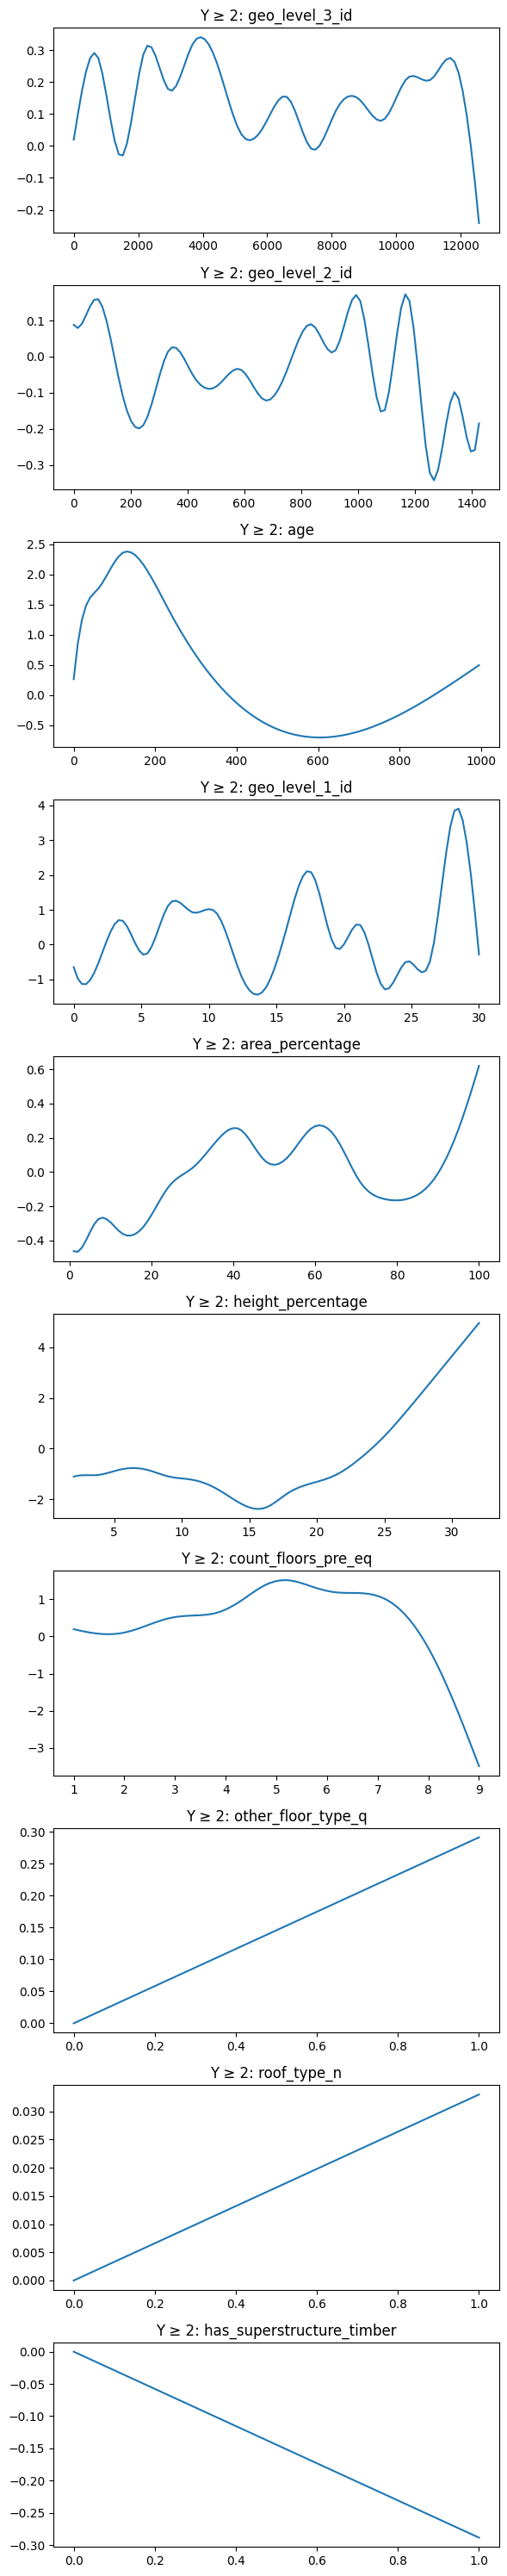

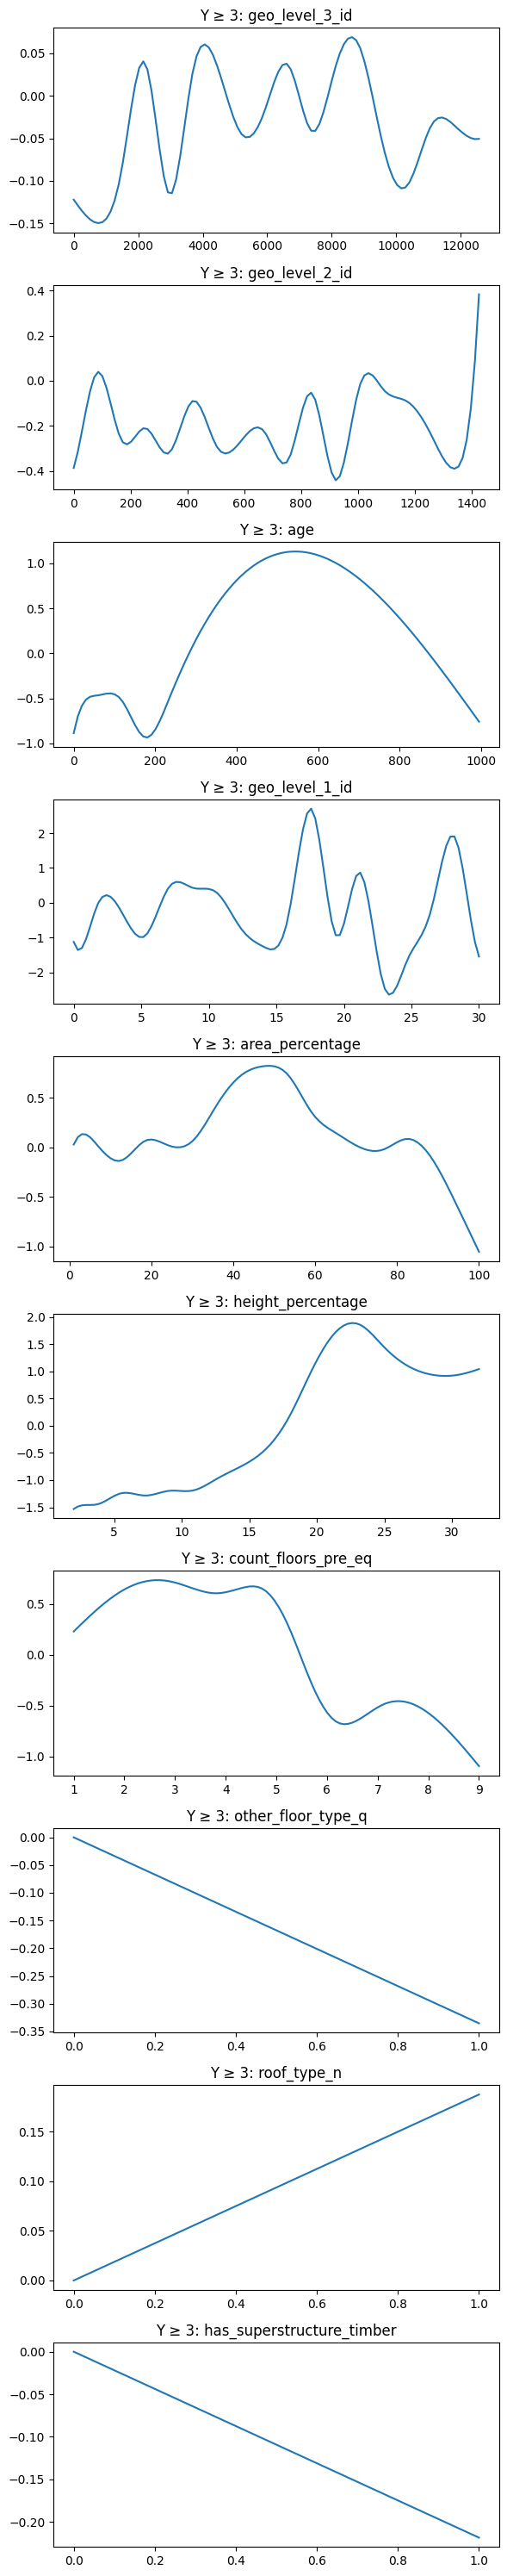

In [11]:
import matplotlib.pyplot as plt

def plot_gam_top(gam, X, idx_list, title):
    fig, axs = plt.subplots(len(idx_list), 1, figsize=(6, 3*len(idx_list)))

    if len(idx_list) == 1:
        axs = [axs]

    for k, i in enumerate(idx_list):
        XX = gam.generate_X_grid(term=i)
        pdep = gam.partial_dependence(term=i, X=XX)

        axs[k].plot(XX[:, i], pdep)
        axs[k].set_title(f"{title}: {X.columns[i]}")

    plt.tight_layout()
    plt.show()
    
plot_gam_top(gam_2, X_sample, top_idx, "Y ≥ 2")
plot_gam_top(gam_3, X_sample, top_idx, "Y ≥ 3")

interpretation of values on y-axis: relative effect on log-odds: <0: decrease the corresponding porb, >0: increase the prob

To save computation, we use s(i)